In [26]:
import numpy as np
import pandas as pd
from pymgrid import Microgrid
import matplotlib.pyplot as plt
from pymgrid.modules import  BatteryModule, LoadModule, RenewableModule, GridModule

In [27]:
np.random.seed(42)
HORAS = 24

### Consumo dos Equipamentos Smart

In [28]:
# tudo em Kwh
standby = 0.03
perfil_residencia = np.array([
    0.8, 0.8, 0.7, 0.7, 0.8, 0.9, #00h-05h (madrugada)
    1.2, 1.8, 1.5, 1.0, 0.9, 0.9, # 06h-11h (manhã: chuveiro, cafeteira)
    1.1, 1.0, 0.9, 0.9, 1.0, 1.4, # 12h-17h (tarde)
    2.2, 2.5, 2.0, 1.6, 1.2, 1.0, # 18h-23h (noite: TV, AC, chuveiro, lavadora)
])

In [29]:
carga_kwh = perfil_residencia + standby

### Geração Solar

In [30]:
horas = np.arange(HORAS)
geracao_solar = np.clip(3.5 * np.sin((horas - 6) * np.pi / 12), 0, None)
geracao_solar[(horas < 6) | (horas > 18)] = 0 # sem sol à noite

### Preço de compra e venda de energia da rede

In [31]:
tarifa_import = np.where((horas >= 18) & (horas <= 21), 1.20, 0.55) # ponta mais cara
tarifa_export = tarifa_import * 0.5 # venda de execedente vale menos

grid_ts = pd.DataFrame({
    "grid_price_import": tarifa_import,
    "grid_price_export": tarifa_export,
    "grid_co2": np.full(HORAS, 0.4),
})

In [32]:
# Eu posso criar uma lista com cada equipamento e associar 
# um valor de gasto a esse equipamento e a variação de ligação
# para o MPC escolher se a maquina vai ficar ligada ou não

###  Módulos da Residência

In [33]:
bateria = BatteryModule(
    min_capacity = 0.5,
    max_capacity = 10,
    max_charge = 3,
    max_discharge = 3,
    efficiency = 0.95,
    init_soc = 0.5,
)

carga = LoadModule(time_series=carga_kwh)
solar = RenewableModule(time_series=geracao_solar)
rede = GridModule(max_import=5, max_export=3, time_series=grid_ts)

casa = Microgrid([bateria, ("pv", solar), carga, rede])

In [46]:
def escolher_acao(casa):
    return casa.sample_action(strict_bound=True)

### Simulação da residência

In [47]:
print("Simulando 1 dia na residência inteligente\n")

for hora in range(HORAS):
    acao = escolher_acao(casa)
    casa.run(acao, normalized=True)

log = casa.get_log()

Simulando 1 dia na residência inteligente



In [ ]:
resumo = pd.DataFrame({
    "hora": range(HORAS),
    "consumo_kwh": carga_kwh.round(2),
    "solar_kwh": geracao_solar.round(2),
    "soc_bateria_%": (log[("battery", 0, "soc")] * 100).round(0).values,
    "compra_rede_kwh": log[("grid", 0, "grid_import")].round(2).values,
    "venda_rede_kwh": log[("grid", 0, "grid_export")].round(2).values,
    "custo_hora_R$": (-log[("balance", 0, "reward")]).round(2).values,
})

In [ ]:

print(resumo.to_string(index=False))
print("\n--- Resumo do dia ---")
print(f"Consumo total:          {resumo['consumo_kwh'].sum():.2f} kWh")
print(f"Geração solar total:    {resumo['solar_kwh'].sum():.2f} kWh")
print(f"Energia comprada da rede: {resumo['compra_rede_kwh'].sum():.2f} kWh")
print(f"Energia vendida à rede:   {resumo['venda_rede_kwh'].sum():.2f} kWh")
print(f"Custo total do dia (R$): {resumo['custo_hora_R$'].sum():.2f}")
print(f"SOC final da bateria:   {resumo['soc_bateria_%'].iloc[-1]:.0f}%")


 hora  consumo_kwh  solar_kwh  soc_bateria_%  compra_rede_kwh  venda_rede_kwh  custo_hora_R$
    0         0.83       0.00           50.0             0.00            1.52          21.83
    1         0.83       0.00           49.0             3.20            0.00          11.84
    2         0.73       0.00           21.0             4.16            0.00          11.55
    3         0.73       0.00            8.0             4.37            0.00           7.49
    4         0.83       0.00           18.0             0.00            1.43          49.88
    5         0.93       0.00           45.0             0.00            0.40          42.03
    6         1.23       0.00           72.0             0.00            0.83          27.23
    7         1.83       0.91           79.0             0.00            0.15          -0.04
    8         1.53       1.75           58.0             1.34            0.00           0.74
    9         1.03       2.47           72.0             3.42         

In [ ]:
tempo = resumo['hora'].to_numpy()
energia_consumida = resumo['consumo_kwh'].to_numpy()
energia_solar = resumo['solar_kwh'].to_numpy()

Text(0.5, 1.0, 'Energia Consumida ao Longo do Dia')

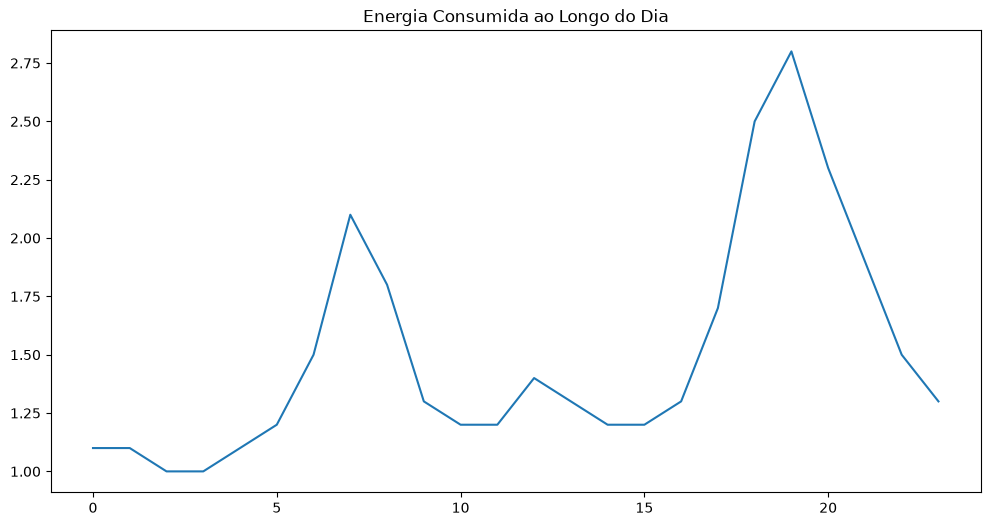

In [ ]:
# ENERGIA CONSUMIDA AO LONGO DO DIA

plt.figure(figsize=(12, 6))
plt.plot(tempo, energia_consumida, label='Energia Consumida')
plt.title('Energia Consumida ao Longo do Dia')